# Variabili d'ambiente


In [34]:
import os
import pandas as pd
import requests
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import seaborn as sns
import calendar as cal
import matplotlib.patches as mpatches

load_dotenv(override=True)
token = os.getenv("NOTION_TOKEN").strip()
Musc = os.getenv("Musc").strip()
Wei = os.getenv("Wei").strip()
Exce = os.getenv("Exce").strip()
HEADERS = {
    "Authorization": f"Bearer {token}",
    "Notion-Version": "2025-09-03",
    "Content-Type": "application/json"
}

## Creazione Funzioni per creare i dataframe a partire dai 3 dataset di notion

In [ ]:


def extract_property(prop: dict, relation_map: dict = {}):
    ptype = prop["type"]
    extractors = {
        "title":        lambda p: p["title"][0]["plain_text"] if p["title"] else None,
        "rich_text":    lambda p: p["rich_text"][0]["plain_text"] if p["rich_text"] else None,
        "number":       lambda p: p["number"],
        "select":       lambda p: p["select"]["name"] if p["select"] else None,
        "multi_select": lambda p: [s["name"] for s in p["multi_select"]],
        "date":         lambda p: p["date"]["start"] if p["date"] else None,
        "checkbox":     lambda p: p["checkbox"],
        "url":          lambda p: p["url"],
        "formula":      lambda p: p["formula"].get("number") or p["formula"].get("string"),
        "relation":     lambda p: [relation_map.get(r["id"], r["id"]) for r in p["relation"]] if p["relation"] else None,
    }
    return extractors.get(ptype, lambda p: None)(prop)


def notion_datasource_to_df(data_source_id: str, relation_maps: dict = {}) -> pd.DataFrame:
    """
    data_source_id: ID del data source principale
    relation_maps: dizionario {nome_colonna: id_map} per risolvere le relation
    """
    url = f"https://api.notion.com/v1/data_sources/{data_source_id}/query"
    rows = []
    payload = {}

    while True:
        response = requests.post(url, headers=HEADERS, json=payload)
        data = response.json()

        for page in data["results"]:
            row = {"page_id": page["id"]}
            for col_name, prop in page["properties"].items():
                rel_map = relation_maps.get(col_name, {})
                row[col_name] = extract_property(prop, rel_map)
            rows.append(row)

        if data["has_more"]:
            payload["start_cursor"] = data["next_cursor"]
        else:
            break

    return pd.DataFrame(rows)

### Creazione dei 3 dataframe

In [36]:
muscles = notion_datasource_to_df(Musc)
excercices = notion_datasource_to_df(Exce)

weight = notion_datasource_to_df(Wei)
weight.drop(columns=['page_id','0'], inplace=True)
muscles['Exercise'].unique()

200
{'object': 'list', 'results': [{'object': 'page', 'id': '30cf7c61-2182-8009-ab97-d9e0800d8ac1', 'created_time': '2026-02-19T08:24:00.000Z', 'last_edited_time': '2026-02-19T08:24:00.000Z', 'created_by': {'object': 'user', 'id': '2004520f-ab18-4811-91cc-3699d3c619c5'}, 'last_edited_by': {'object': 'user', 'id': '2004520f-ab18-4811-91cc-3699d3c619c5'}, 'cover': None, 'icon': None, 'parent': {'type': 'data_source_id', 'data_source_id': '30cf7c61-2182-80a9-9eda-000bab2a315b', 'database_id': '30cf7c61-2182-80ae-9537-d921c1b66d03'}, 'in_trash': False, 'is_archived': False, 'is_locked': False, 'properties': {'Type': {'id': 'ADWn', 'type': 'select', 'select': {'id': 'x<]]', 'name': 'Pull', 'color': 'yellow'}}, 'Muscle Group': {'id': 'Of%3F%7D', 'type': 'select', 'select': {'id': 'D};|', 'name': 'Bicipiti', 'color': 'blue'}}, 'Secondary Muscle': {'id': 'fPis', 'type': 'select', 'select': {'id': 'EvC]', 'name': '—', 'color': 'green'}}, 'Primary Muscle': {'id': 'nTts', 'type': 'select', 'selec

array(['Curl Bilanciere', 'Seated Row', 'Rematore Manubrio', 'Pull Down',
       'Croci Cavi', 'Panca Inclinata', 'Rematore Bilanciere', 'Squat',
       'Tricipiti Cavi', 'Dips', 'Push Up', 'Military Press',
       'Calf Raises', 'Hammer Curl', 'Crunch', 'Pull Up', 'Affondi',
       'Face Pull', 'Leg Press', 'Leg Curl', 'Arnold Press', 'Leg Raise',
       'Lateral Raises', 'Chin Up', 'Curl Manubri', 'Shrugs',
       'Russian Twist', 'Cable Crunch', 'Hammer Pullups', 'Plank',
       'Skull Crusher', 'Panca Piana', 'Affondi Rumeni', 'Pulley',
       'Stacco a Gambe Tese', 'Tirate al Mento'], dtype=object)

### Merge e pulizia iniziale dei dataframe Muscles e Exercises

In [37]:

excercices['Exercise'] = excercices['Exercise'].apply(lambda x: x[0] if isinstance(x, list) else x)
df = pd.merge(excercices, muscles, left_on='Exercise', right_on='page_id', how='left')

df.drop(columns=['page_id_y','page_id_x','Exercise_x'], inplace=True)
df.rename(columns={'Exercise_y': 'Exercise'}, inplace=True)
df

,Volume,Sets,Weight,Reps,Muscle,Date1,Date,Type,Muscle Group,Secondary Muscle,Primary Muscle,Equipment,Exercise
0,624,3,26,8,Bicipiti,2026-02-18,None,Pull,Bicipiti,—,Bicipiti,Bilanciere,Curl Bilanciere
1,768,3,32,8,Spalle,2026-02-17,None,Push,Spalle,Tricipiti,Deltoidi,Bilanciere,Military Press
2,468,3,26,6,Bicipiti,2026-02-18,None,Pull,Bicipiti,Bicipiti,Brachiale,Manubri,Hammer Curl
3,704,4,22,8,Spalle,2026-02-17,None,Push,Spalle,—,Deltoidi Laterali,Manubri,Lateral Raises
4,1020,3,34,10,Spalle,2026-02-23,None,Pull,Spalle,Trapezio,Deltoidi,Bilanciere,Tirate al Mento
...,...,...,...,...,...,...,...,...,...,...,...,...,...
80,300,5,20,3,Tricipiti,2026-03-22,Push,Push,Tricipiti,Tricipiti,Pettorali,Bodyweight,Dips
81,528,2,22,12,Spalle,2026-03-22,Push,Push,Spalle,—,Deltoidi Laterali,Manubri,Lateral Raises
82,720,3,40,6,Spalle,2026-03-22,Push,Push,Spalle,Tricipiti,Deltoidi,Bilanciere,Military Press
83,1248,4,52,6,Petto,2026-03-22,Push,Push,Petto,Deltoidi,Pettorali,Bilanciere,Panca Piana


### Pulizia e rinominazione delle colonne del nuovo dataframe chiamato per comodità df

In [38]:


#eliminazione collona Type e Volume
if 'Type' in df.columns:
    df.drop(columns=['Type', 'Volume'], inplace=True)
#rinominiazione colonna Date in Split e Date1 in Date
if 'Date1' in df.columns:
    df.rename(columns={'Date': 'Split', 'Date1': 'Date'}, inplace=True)
#eliminazione [] dalla colonna Exercise
if 'Exercise' in df.columns:
    df['Exercise'] = df['Exercise'].apply(lambda x: x[0] if isinstance(x, list) and len(x) > 0 else x)



### Creazione della logica per il volume percepito da ogni gruppo muscolare
#### da modificare/eliminare i fattori di conversione per ogni muscolo, magari anche estendendo la logica ai muscoli secondari


In [39]:
weight['Date'] = pd.to_datetime(weight['Date'])
df['Date'] = pd.to_datetime(df['Date'])

def get_body_weight(date):
    weights_before_date = weight[weight['Date'] <= date]
    if not weights_before_date.empty:
        return weights_before_date.iloc[-1]['Weight']
    return None

def adjust_weight_for_bodyweight(exercise, w, date):
    body_weight_exercises = ['Dips', 'Chin Up', 'Pull Up', 'Hammer Pullups', 'Push Up', 'Leg Raise']
    if exercise in body_weight_exercises:
        body_weight = get_body_weight(date)
        if body_weight is not None:
            if exercise == 'Leg Raise':
                w += body_weight * 0.30
            else:
                w += body_weight
    return w

# Aggiusta peso corporeo
df['Weight'] = df.apply(
    lambda row: adjust_weight_for_bodyweight(row['Exercise'], row['Weight'], row['Date']), axis=1
)

# Tonnage classico
df['Volume'] = df['Sets'] * df['Reps'] * df['Weight']


In [40]:
body_weight_exercises = ['Dips', 'Chin Up', 'Pull Up', 'Hammer Pullups', 'Push Up', 'Leg Raise']
latest_bw = weight.sort_values('Date').iloc[-1]['Weight']

rm_df = pd.DataFrame(
    estimated_1rm.items(),
    columns=['Exercise', 'Estimated 1RM']
).sort_values('Estimated 1RM', ascending=False).reset_index(drop=True)

# Sottrai il peso corporeo per gli esercizi a corpo libero
rm_df['Overload 1RM'] = rm_df.apply(
    lambda row: round(row['Estimated 1RM'] - latest_bw, 2)
    if row['Exercise'] in body_weight_exercises else None, axis=1
)

rm_df['Estimated 1RM'] = rm_df['Estimated 1RM'].round(2)
rm_df


NameError: name 'estimated_1rm' is not defined

### Grafico di prova per vedere il volume totale diviso per i vari gruppi muscolari

<Axes: xlabel='Muscle', ylabel='Volume'>

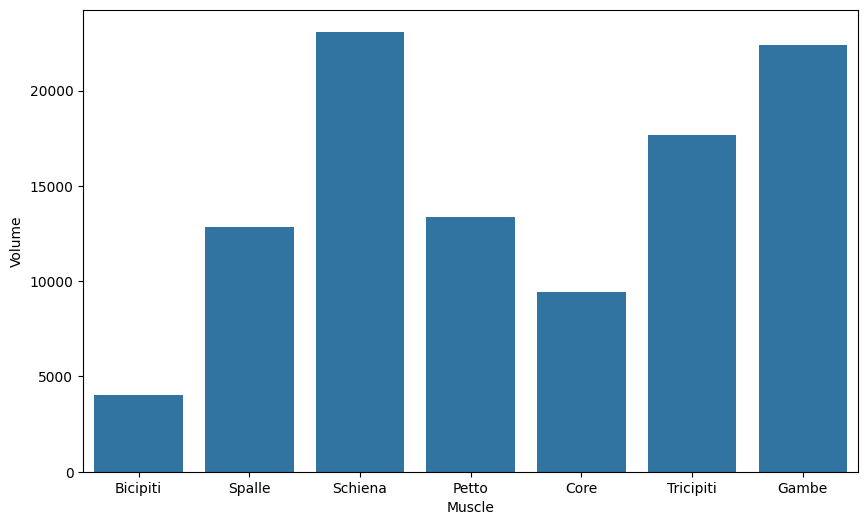

In [ ]:
#histogramma del volume totale per ogni gruppo muscolare con come asse x i gruppi muscolare e come asse y il volume totale

plt.figure(figsize=(10, 6))
sns.barplot(x='Muscle', y='Volume', data=df, estimator=sum, errorbar=None)

### Heatmap calendario con tutti i giorni in cui c'è un allenamneto con il colore in base al volume giornaliero


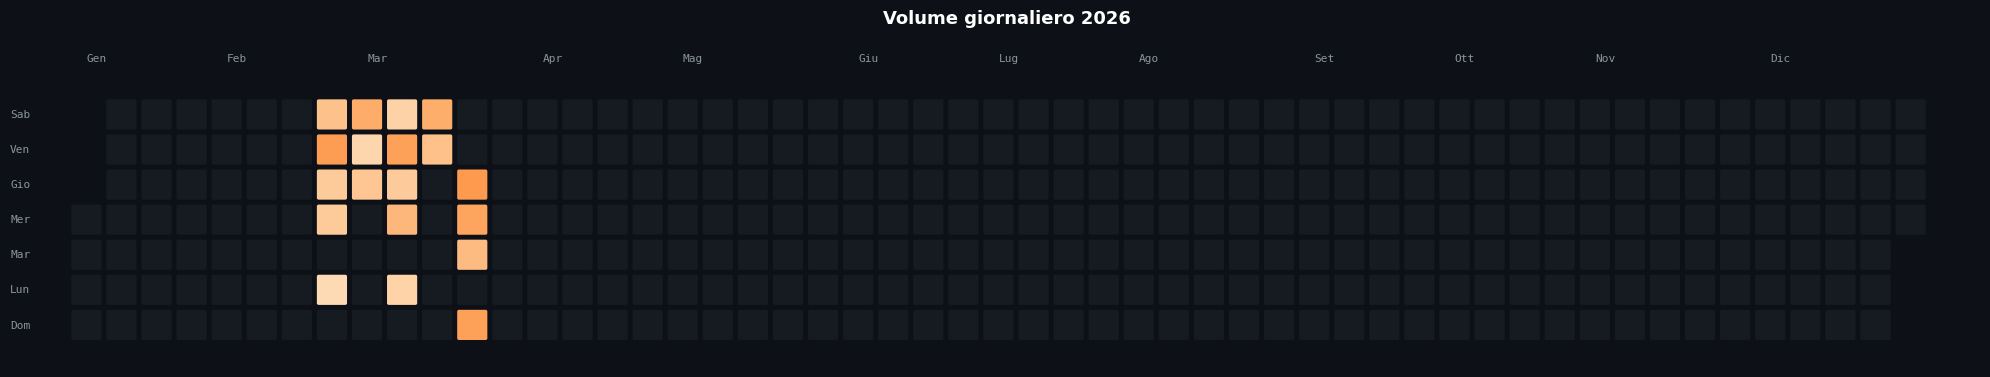

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
train_2026 = df[df['Date'].dt.year == 2026].copy()

daily_counts = train_2026.groupby('Date')['Volume'].sum().reset_index(name='volume')

calendar_df = pd.DataFrame({'Date': pd.date_range('2026-01-01', '2026-12-31', freq='D')})
calendar_df = calendar_df.merge(daily_counts, on='Date', how='left')
calendar_df['volume'] = calendar_df['volume'].fillna(0).astype(float)

start_weekday = pd.Timestamp('2026-01-01').weekday()
calendar_df['week'] = ((calendar_df['Date'] - pd.Timestamp('2026-01-01')).dt.days + start_weekday) // 7
calendar_df['weekday'] = calendar_df['Date'].dt.weekday

fig, ax = plt.subplots(figsize=(20, 3.8))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#0d1117')

max_val = calendar_df['volume'].max()
cmap = plt.cm.Oranges

for _, row in calendar_df.iterrows():
    x = row['week']
    y = 6 - row['weekday']
    val = row['volume']

    if val == 0:
        color = '#161b22'
    else:
        # Invertito: basso volume → 0.85 (scuro), alto volume → 0.2 (chiaro)
        norm = val / max_val if max_val > 0 else 0
        color = cmap(0.85 - 0.65 * norm)

    rect = mpatches.FancyBboxPatch(
        (x - 0.38, y - 0.38), 0.76, 0.76,
        boxstyle="round,pad=0.05",
        facecolor=color,
        edgecolor='none'
    )
    ax.add_patch(rect)

ax.set_xlim(-1.5, 54)
ax.set_ylim(-1.2, 8.2)
ax.set_aspect('equal')
ax.axis('off')

# Labels giorni (in italiano)
days = ['Dom', 'Lun', 'Mar', 'Mer', 'Gio', 'Ven', 'Sab']
for i, day in enumerate(days):
    ax.text(-1.6, i, day, color='#8b949e', va='center', ha='right', fontsize=8, fontfamily='monospace')

# Labels mesi
months = ['Gen', 'Feb', 'Mar', 'Apr', 'Mag', 'Giu',
          'Lug', 'Ago', 'Set', 'Ott', 'Nov', 'Dic']
for month_num, month_name in enumerate(months, start=1):
    first_day = pd.Timestamp(f'2026-{month_num:02d}-01')
    week_num = ((first_day - pd.Timestamp('2026-01-01')).days + start_weekday) // 7
    ax.text(week_num, 7.5, month_name, color='#8b949e', fontsize=8, ha='left', fontfamily='monospace')

# # Legenda volume
# legend_x = 46
# legend_y = -0.9
# ax.text(legend_x, legend_y - 0.3, 'meno', color='#8b949e', fontsize=7, ha='center', fontfamily='monospace')
# ax.text(legend_x + 4, legend_y - 0.3, 'più', color='#8b949e', fontsize=7, ha='center', fontfamily='monospace')
# for i, intensity in enumerate([0.85, 0.70, 0.55, 0.40, 0.25]):
#     rect = mpatches.FancyBboxPatch(
#         (legend_x + i * 0.85, legend_y), 0.76, 0.76,
#         boxstyle="round,pad=0.05",
#         facecolor=cmap(intensity),
#         edgecolor='none'
#     )
#     ax.add_patch(rect)

ax.set_title("Volume giornaliero 2026", color='white', pad=10, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
